# 03 — Computing radiative quantities with Smart-G

This notebook shows how to use the individual Smart-G samplers and the convenience `RadiativePipeline` to compute the six radiative quantities needed for TOA simulation.

| Variable | Symbol | Sampler |
|---|---|---|
| Direct downward transmittance | $T_{dir\downarrow}$ | `SmartgSampler_Tdir_down` |
| Direct upward transmittance | $T_{dir\uparrow}$ | `SmartgSampler_Tdir_up` |
| Diffuse downward transmittance | $T_{dif\downarrow}$ | `SmartgSampler_Tdif_down` |
| Diffuse upward transmittance | $T_{dif\uparrow}$ | `SmartgSampler_Tdif_up` |
| Atmospheric path reflectance | $\rho_{atm}$ | `SmartgSampler_Rho_atm` |
| Spherical albedo | $s$ | `SmartgSampler_Sph_alb` |

**Requires:** a configured `SMARTG_DIR_AUXDATA` environment variable and a GPU.

In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from adjeff.atmosphere import AtmoConfig, GeoConfig, SpectralConfig
from adjeff.core import ImageDict, S2Band
from adjeff.modules.samplers import (
    RadiativePipeline,
    SmartgSampler_Tdir_down,
    SmartgSampler_Tdir_up,
    SmartgSampler_Rho_atm,
    SmartgSampler_Sph_alb,
)

# Verify Smart-G is configured
assert "SMARTG_DIR_AUXDATA" in os.environ, (
    "Set SMARTG_DIR_AUXDATA to the Smart-G auxiliary data directory."
)

## 3.1 — Single atmospheric state

The simplest case: one value per parameter, all results are scalars (per band per wavelength).

In [2]:
BANDS = [S2Band.B02, S2Band.B03, S2Band.B04]

atmo = AtmoConfig(
    aot=xr.DataArray([0.1], dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)

geo = GeoConfig(
    sza=xr.DataArray([30.0], dims=["sza"]),
    vza=xr.DataArray([10.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([120.0], dims=["vaa"]),
)

spectral = SpectralConfig.from_bands(BANDS)
scene = ImageDict({band: xr.Dataset() for band in BANDS})

# Run the full radiative pipeline
pipeline = RadiativePipeline(
    atmo_config=atmo,
    geo_config=geo,
    spectral_config=spectral,
    remove_rayleigh=False,
)
scene = pipeline(scene)
print(scene)

2026-04-14 15:44:43 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=c5b9de7b module=SmartgSampler_Tdir_down
2026-04-14 15:44:43 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'sza']
2026-04-14 15:44:43 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} deduplicated=False flat_dims=[]
2026-04-14 15:44:43 [debug    ] Sweep step                     coords={} step=1/1
2026-04-14 15:44:43 [info     ] Computing tdir_down ...        sza=<xarray.DataArray (sza: 1)> Size: 8B
array([30.])
Coordinates:
  * sza      (sza) float64 8B 30.0 wl=<xarray.DataArray (wl: 3)> Size: 24B
array([490., 560., 665.])
Coordinates:
  * wl       (wl) float64 24B 490.0 

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.
2026-04-14 15:44:45 [info     ] tdir_down successfully calculated.
2026-04-14 15:44:45 [debug    ] Reconstructed original dimensions. dims=['wl', 'aot', 'rh', 'href', 'h', 'sza'] shape=(3, 1, 1, 1, 1, 1)
2026-04-14 15:44:45 [info     ] Computed tdir_down.            dims=('wl', 'aot', 'rh', 'href', 'h', 'sza')
2026-04-14 15:44:45 [info     ] Computation finished           key=c5b9de7b module=SmartgSampler_Tdir_down vars=['tdir_down']
2026-04-14 15:44:45 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=14c5e942 module=SmartgSampler_Tdir_up
2026-04-14 15:44:45 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'vza': ['vza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'vza']
2026-04-14 15:44:45 [debug    ] Initialization finshed.        arrays={'wl': ['wl

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.
2026-04-14 15:44:46 [info     ] tdir_up successfully calculated.
2026-04-14 15:44:46 [debug    ] Reconstructed original dimensions. dims=['wl', 'aot', 'rh', 'href', 'h', 'vza'] shape=(3, 1, 1, 1, 1, 1)
2026-04-14 15:44:46 [info     ] Computed tdir_up.              dims=('wl', 'aot', 'rh', 'href', 'h', 'vza')
2026-04-14 15:44:46 [info     ] Computation finished           key=14c5e942 module=SmartgSampler_Tdir_up vars=['tdir_up']
2026-04-14 15:44:46 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=1bbabf4c module=SmartgSampler_Sph_alb
2026-04-14 15:44:46 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href']} other=['band_type', 'species'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href']
2026-04-14 15:44:46 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'

...

There is no current context to clear.
2026-04-14 15:44:53 [info     ] tdif_up successfully calculated.
2026-04-14 15:44:53 [debug    ] Reconstructed original dimensions. dims=['vza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 3, 1, 1, 1, 1)
2026-04-14 15:44:53 [info     ] Computed tdif_up.              dims=('vza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-14 15:44:53 [info     ] Computation finished           key=c797d696 module=SmartgSampler_Tdif_up vars=['tdif_up']
2026-04-14 15:44:53 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=8a032ac4 module=SmartgSampler_Tdif_down
2026-04-14 15:44:53 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'sza']
2026-04-14 15:44:53 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 

Box(children=(FloatProgress(value=0.0, max=90000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-14 15:44:55 [info     ] tdif_down successfully calculated.
2026-04-14 15:44:55 [debug    ] Reconstructed original dimensions. dims=['sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 3, 1, 1, 1, 1)
2026-04-14 15:44:55 [info     ] Computed tdif_down.            dims=('sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-14 15:44:55 [info     ] Computation finished           key=8a032ac4 module=SmartgSampler_Tdif_down vars=['tdif_down']
2026-04-14 15:44:55 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=e68b0eff module=SmartgSampler_Rho_atm
2026-04-14 15:44:55 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'vza', 'sza']
2026-04-14 15:44:55 [debug    ] Initialization finshed.   

Box(children=(FloatProgress(value=0.0, max=60000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-14 15:44:58 [info     ] rho_atm successfully calculated.
2026-04-14 15:44:58 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 1, 3, 1, 1, 1, 1)
2026-04-14 15:44:58 [info     ] Computed rho_atm.              dims=('vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-14 15:44:58 [info     ] Computation finished           key=e68b0eff module=SmartgSampler_Rho_atm vars=['rho_atm']
ImageDict(
  S2Band.B02(490.0nm): ['tdir_down', 'tdir_up', 'sph_alb', 'tdif_up', 'tdif_down', 'rho_atm']
  S2Band.B03(560.0nm): ['tdir_down', 'tdir_up', 'sph_alb', 'tdif_up', 'tdif_down', 'rho_atm']
  S2Band.B04(665.0nm): ['tdir_down', 'tdir_up', 'sph_alb', 'tdif_up', 'tdif_down', 'rho_atm']
)


In [3]:
# Inspect results for B02
ds = scene[S2Band.B02]
print("Variables computed:")
for var in ds.data_vars:
    da = ds[var]
    print(f"  {var:12s}  dims={list(da.dims)}  value={float(da.squeeze()):.5f}")

Variables computed:
  tdir_down     dims=['aot', 'rh', 'href', 'h', 'sza']  value=0.72989
  tdir_up       dims=['aot', 'rh', 'href', 'h', 'vza']  value=0.75814
  sph_alb       dims=['aot', 'rh', 'href', 'h']  value=0.14662
  tdif_up       dims=['vza', 'aot', 'rh', 'href', 'h']  value=0.15949
  tdif_down     dims=['sza', 'aot', 'rh', 'href', 'h']  value=0.17599
  rho_atm       dims=['vza', 'sza', 'aot', 'rh', 'href', 'h']  value=0.06186


The resulting dataset contains data variables `tdir_down`, `tdir_up`, `sph_alb`, `tdif_up`, `tdif_down` and `rho_atm` with single value dimensions. The resulting values must be squeezed in order to be displayed as floats. This design choice was made to keep track of each input parameters used for the computation.

For instance, if another module further use the value of `tdir_down` for an operation, for instance multiplying with an input image of dimensions `(x, y)`, the input image will automatically be broadcasted in the `aot`, `rh`, etc. axes, resulting in an images with dimensions ``(x, y, aot, rh, href, h, sza)`.

## 3.2 — AOT sweep across multiple bands

Let's now sweep over different AOT values. 

In [4]:
aot_values = np.array([0.02, 0.05, 0.10, 0.20, 0.40, 0.80])

atmo_sweep = AtmoConfig(
    aot=xr.DataArray(aot_values, dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)

pipeline_sweep = RadiativePipeline(
    atmo_config=atmo_sweep,
    geo_config=geo,
    spectral_config=spectral,
    remove_rayleigh=False,
)
scene_sweep = pipeline_sweep(ImageDict({band: xr.Dataset() for band in BANDS}))

2026-04-14 15:44:58 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=35b762b5 module=SmartgSampler_Tdir_down
2026-04-14 15:44:58 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'sza']
2026-04-14 15:44:58 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} deduplicated=False flat_dims=[]
2026-04-14 15:44:58 [debug    ] Sweep step                     coords={} step=1/1
2026-04-14 15:44:58 [info     ] Computing tdir_down ...        sza=<xarray.DataArray (sza: 1)> Size: 8B
array([30.])
Coordinates:
  * sza      (sza) float64 8B 30.0 wl=<xarray.DataArray (wl: 3)> Size: 24B
array([490., 560., 665.])
Coordinates:
  * wl       (wl) float64 24B 490.0 

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.
2026-04-14 15:45:00 [info     ] tdir_down successfully calculated.
2026-04-14 15:45:00 [debug    ] Reconstructed original dimensions. dims=['wl', 'aot', 'rh', 'href', 'h', 'sza'] shape=(3, 6, 1, 1, 1, 1)
2026-04-14 15:45:00 [info     ] Computed tdir_down.            dims=('wl', 'aot', 'rh', 'href', 'h', 'sza')
2026-04-14 15:45:00 [info     ] Computation finished           key=35b762b5 module=SmartgSampler_Tdir_down vars=['tdir_down']
2026-04-14 15:45:00 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=3b546645 module=SmartgSampler_Tdir_up
2026-04-14 15:45:00 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'vza': ['vza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'vza']
2026-04-14 15:45:00 [debug    ] Initialization finshed.        arrays={'wl': ['wl

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.
2026-04-14 15:45:02 [info     ] tdir_up successfully calculated.
2026-04-14 15:45:02 [debug    ] Reconstructed original dimensions. dims=['wl', 'aot', 'rh', 'href', 'h', 'vza'] shape=(3, 6, 1, 1, 1, 1)
2026-04-14 15:45:02 [info     ] Computed tdir_up.              dims=('wl', 'aot', 'rh', 'href', 'h', 'vza')
2026-04-14 15:45:02 [info     ] Computation finished           key=3b546645 module=SmartgSampler_Tdir_up vars=['tdir_up']
2026-04-14 15:45:02 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=52923957 module=SmartgSampler_Sph_alb
2026-04-14 15:45:02 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href']} other=['band_type', 'species'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href']
2026-04-14 15:45:02 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'

...

There is no current context to clear.
2026-04-14 15:45:55 [info     ] tdif_up successfully calculated.
2026-04-14 15:45:55 [debug    ] Reconstructed original dimensions. dims=['vza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 3, 6, 1, 1, 1)
2026-04-14 15:45:55 [info     ] Computed tdif_up.              dims=('vza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-14 15:45:55 [info     ] Computation finished           key=9560c93f module=SmartgSampler_Tdif_up vars=['tdif_up']
2026-04-14 15:45:55 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=9e83cc93 module=SmartgSampler_Tdif_down
2026-04-14 15:45:55 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'sza']
2026-04-14 15:45:55 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 

Box(children=(FloatProgress(value=0.0, max=540000000.0), Label(value='')), layout=Layout(align_items='center',…

There is no current context to clear.
2026-04-14 15:46:13 [info     ] tdif_down successfully calculated.
2026-04-14 15:46:13 [debug    ] Reconstructed original dimensions. dims=['sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 3, 6, 1, 1, 1)
2026-04-14 15:46:13 [info     ] Computed tdif_down.            dims=('sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-14 15:46:13 [info     ] Computation finished           key=9e83cc93 module=SmartgSampler_Tdif_down vars=['tdif_down']
2026-04-14 15:46:13 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=e639e987 module=SmartgSampler_Rho_atm
2026-04-14 15:46:13 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'vza', 'sza']
2026-04-14 15:46:13 [debug    ] Initialization finshed.   

Box(children=(FloatProgress(value=0.0, max=360000000.0), Label(value='')), layout=Layout(align_items='center',…

There is no current context to clear.
2026-04-14 15:46:27 [info     ] rho_atm successfully calculated.
2026-04-14 15:46:27 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 1, 3, 6, 1, 1, 1)
2026-04-14 15:46:27 [info     ] Computed rho_atm.              dims=('vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-14 15:46:27 [info     ] Computation finished           key=e639e987 module=SmartgSampler_Rho_atm vars=['rho_atm']


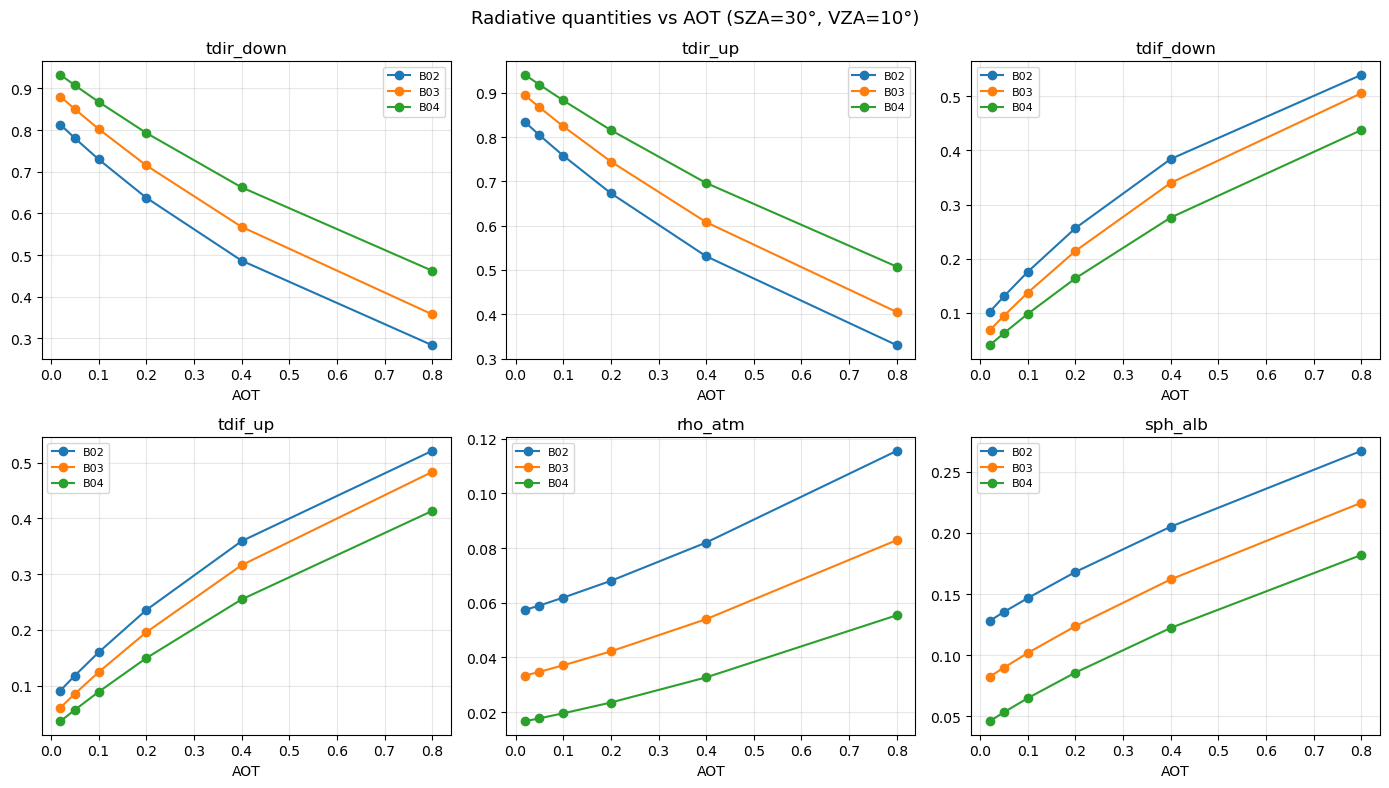

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
vars_to_plot = [
    "tdir_down", 
    "tdir_up", 
    "tdif_down", 
    "tdif_up", 
    "rho_atm", 
    "sph_alb"
]
colors = {S2Band.B02: "C0", S2Band.B03: "C1", S2Band.B04: "C2"}

for ax, var in zip(axes.flat, vars_to_plot):
    for band in BANDS:
        da = scene_sweep[band][var].squeeze()
        # squeeze out all dims except aot
        da = da.squeeze(drop=True)
        ax.plot(
            aot_values, 
            da.values, 
            marker="o", 
            label=band.id, 
            color=colors[band]
        )
    ax.set_title(var)
    ax.set_xlabel("AOT")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Radiative quantities vs AOT (SZA=30°, VZA=10°)", fontsize=13)
plt.tight_layout()
plt.show()

## 3.3 — Caching

Results can be cached to disk so that re-running the same configuration does not run the module core function.

In [8]:
import time
from adjeff.utils import CacheStore

cache = CacheStore("./adjeff_cache")

pipeline_cached = RadiativePipeline(
    atmo_config=atmo,
    geo_config=geo,
    spectral_config=spectral,
    remove_rayleigh=False,
    cache=cache,
)

# First run — computes and saves
t0 = time.perf_counter()
scene_c1 = pipeline_cached(ImageDict({band: xr.Dataset() for band in BANDS}))
t1 = time.perf_counter()
print(f"First run : {t1 - t0:.2f}s")

# Second run — loads from cache
t0 = time.perf_counter()
scene_c2 = pipeline_cached(ImageDict({band: xr.Dataset() for band in BANDS}))
t1 = time.perf_counter()
print(f"Cache hit : {t1 - t0:.2f}s")

2026-04-14 15:48:12 [debug    ] Cache was hit.                 bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=c5b9de7b vars=['tdir_down']
2026-04-14 15:48:12 [info     ] cache hit — skipping compute   bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=c5b9de7b module=SmartgSampler_Tdir_down vars=['tdir_down']
2026-04-14 15:48:12 [debug    ] Cache was hit.                 bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=14c5e942 vars=['tdir_up']
2026-04-14 15:48:12 [info     ] cache hit — skipping compute   bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=14c5e942 module=SmartgSampler_Tdir_up vars=['tdir_up']
2026-04-14 15:48:12 [debug    ] Cache was hit.                 bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=1bbabf4c vars=['sph_alb']
2026-04-14 15:48:12 [info     ] cache hit — skipping compute   bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B0

## 3.4 — Angular sweep: effect of SZA on transmittances

Here is another exemple where the effect of the Sun Zenith Angle on the computed direct downward transmittance is illustrated.

2026-04-14 15:48:21 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=954ca7b1 module=SmartgSampler_Tdir_down
2026-04-14 15:48:21 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'sza']
2026-04-14 15:48:21 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} deduplicated=False flat_dims=[]
2026-04-14 15:48:21 [debug    ] Sweep step                     coords={} step=1/1
2026-04-14 15:48:21 [info     ] Computing tdir_down ...        sza=<xarray.DataArray (sza: 15)> Size: 120B
array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70.])
Coordinates:
  * sza      (sza) float64 120B 0.0 5.0 10.0 15.0 20.0 ... 55.0 60.0 65.0 70.0 wl=<xarray.DataArray (wl: 1)> Size: 8B
a

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.
2026-04-14 15:48:22 [info     ] tdir_down successfully calculated.
2026-04-14 15:48:22 [debug    ] Reconstructed original dimensions. dims=['wl', 'aot', 'rh', 'href', 'h', 'sza'] shape=(1, 1, 1, 1, 1, 15)
2026-04-14 15:48:22 [info     ] Computed tdir_down.            dims=('wl', 'aot', 'rh', 'href', 'h', 'sza')
2026-04-14 15:48:22 [info     ] Computation finished           key=954ca7b1 module=SmartgSampler_Tdir_down vars=['tdir_down']
2026-04-14 15:48:22 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=bbbe924b module=SmartgSampler_Tdif_down
2026-04-14 15:48:22 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'sza']
2026-04-14 15:48:22 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': [

Box(children=(FloatProgress(value=0.0, max=450000000.0), Label(value='')), layout=Layout(align_items='center',…

There is no current context to clear.
2026-04-14 15:48:29 [info     ] tdif_down successfully calculated.
2026-04-14 15:48:29 [debug    ] Reconstructed original dimensions. dims=['sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(15, 1, 1, 1, 1, 1)
2026-04-14 15:48:29 [info     ] Computed tdif_down.            dims=('sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-14 15:48:29 [info     ] Computation finished           key=bbbe924b module=SmartgSampler_Tdif_down vars=['tdif_down']


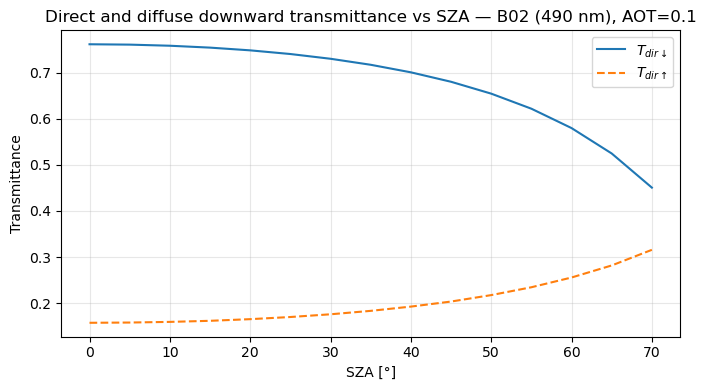

In [9]:
sza_values = np.arange(0.0, 75.0, 5.0)

geo_sza = GeoConfig(
    sza=xr.DataArray(sza_values, dims=["sza"]),
    vza=xr.DataArray([0.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([120.0], dims=["vaa"]),
)

# Use a lighter setup: only tdir samplers (analytical, much faster)
from adjeff.modules.samplers import SmartgSampler_Tdir_down, SmartgSampler_Tdif_down
from adjeff.modules import Pipeline

pipeline_sza = Pipeline([
    SmartgSampler_Tdir_down(
        atmo_config=atmo,
        geo_config=geo_sza,
        spectral_config=SpectralConfig.from_bands([S2Band.B02]),
        remove_rayleigh=False,
    ),
    SmartgSampler_Tdif_down(
        atmo_config=atmo,
        geo_config=geo_sza,
        spectral_config=SpectralConfig.from_bands([S2Band.B02]),
        remove_rayleigh=False,
    ),
])

scene_sza = pipeline_sza(ImageDict({S2Band.B02: xr.Dataset()}))

tdir_down = scene_sza[S2Band.B02]["tdir_down"].squeeze()
tdif_down = scene_sza[S2Band.B02]["tdif_down"].squeeze()

plt.figure(figsize=(7, 4))
plt.plot(sza_values, tdir_down.values, label="$T_{dir\\downarrow}$")
plt.plot(sza_values, tdif_down.values, label="$T_{dir\\uparrow}$", linestyle="--")
plt.xlabel("SZA [°]")
plt.ylabel("Transmittance")
plt.title("Direct and diffuse downward transmittance vs SZA — B02 (490 nm), AOT=0.1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()